# Trabajo Práctico: Predicción de precios de casas

**Aprendizaje Automático 1 — Tecnicatura Universitaria en Inteligencia Artificial (FCEIA - UNR)**

**Integrantes:** Franco Esparza, Franco Renna, Leandro Picó

**Objetivo:** predecir `MEDV` (valor mediano de las viviendas de cada barrio de Boston, en miles de dólares) a partir de 13 características del barrio.

### Contenidos
1. Configuración
2. Carga de datos
3. Datos faltantes y consistencia
4. Limpieza previa al split
5. División train / validación / test
6. Análisis descriptivo
7. Relación con el target y correlación
8. Codificación de variables categóricas
9. Imputación de faltantes
10. Escalado
11. Conclusiones

---
## 1. Configuración

In [1]:
# Importación de librerías y configuración global de gráficos y de pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

# Configuracion global de visualizacion
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 100
})
sns.set_theme(style='whitegrid', palette='viridis')

# Configuracion de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
## 2. Carga de datos

El target `MEDV` es un número continuo, así que el problema es de **regresión**. Las 13 variables explicativas se describen en la sección 6.

In [2]:
# Carga del dataset y definicion del target y de las variables explicativas
df = pd.read_csv('house-prices-tp.csv')

TARGET = 'MEDV'
cols_features = [c for c in df.columns if c != TARGET]

print(f'Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head()

Dimensiones del dataset: 556 filas x 14 columnas


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.0715,0.0000,4.4900,0.0000,0.4490,6.1210,56.8000,3.7476,3.0000,247.0000,18.5000,395.1500,8.4400,22.2000
1,0.0827,0.0000,13.9200,0.0000,0.4370,6.1270,18.4000,5.5027,4.0000,289.0000,16.0000,396.9000,8.5800,23.9000
2,0.1282,12.5000,6.0700,0.0000,0.4090,5.8850,33.0000,6.4980,4.0000,345.0000,18.9000,396.9000,8.7900,20.9000
3,0.0887,21.0000,5.6400,0.0000,0.4390,5.9630,45.7000,6.8147,4.0000,243.0000,16.8000,395.5600,13.4500,19.7000
4,0.1143,0.0000,8.5600,0.0000,0.5200,6.7810,71.3000,2.8561,5.0000,384.0000,20.9000,395.5800,7.6700,26.5000


---
## 3. Datos faltantes y consistencia

Se analiza sobre todo el dataset porque acá solo se cuenta: no se calcula nada que después se use en el modelo.

In [3]:
# Reporte de valores nulos por columna
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df)) * 100

reporte_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': pct_nulos,
    'Tipo': df.dtypes
})

print('Reporte de Valores Nulos:')
print('=' * 50)
print(reporte_nulos)
print(f'\nTotal de celdas con nulos: {nulos.sum()} '
      f'({nulos.sum() / df.size * 100:.4f}% del dataset)')

Reporte de Valores Nulos:
         Nulos  Porcentaje (%)     Tipo
CRIM        23          4.1367  float64
ZN          22          3.9568  float64
INDUS       15          2.6978  float64
CHAS        23          4.1367  float64
NOX         24          4.3165  float64
RM          21          3.7770  float64
AGE         24          4.3165  float64
DIS         15          2.6978  float64
RAD         28          5.0360  float64
TAX         18          3.2374  float64
PTRATIO     28          5.0360  float64
B           22          3.9568  float64
LSTAT       22          3.9568  float64
MEDV        21          3.7770  float64

Total de celdas con nulos: 306 (3.9311% del dataset)


Todas las columnas tienen entre 2,7% y 5% de faltantes, incluido el target. Veamos cómo se reparten entre las filas.

In [4]:
# Faltantes por fila: ¿estan repartidos en muchas filas o concentrados en pocas?
nulos_por_fila = df.isna().sum(axis=1)
p_faltante = df.isna().mean().mean()
filas_esperadas = len(df) * (1 - (1 - p_faltante) ** df.shape[1])  # si faltaran al azar e independientes

print(f'Filas completas: {(nulos_por_fila == 0).sum()}')
print(f'Filas con al menos un faltante: {(nulos_por_fila > 0).sum()} ({(nulos_por_fila > 0).mean() * 100:.2f}%)')
print(f'Filas incompletas esperadas si los faltantes fueran al azar: {filas_esperadas:.0f}')

Filas completas: 506
Filas con al menos un faltante: 50 (8.99%)
Filas incompletas esperadas si los faltantes fueran al azar: 239


In [5]:
# Duplicados, valores fuera del dominio posible y valores no enteros de RAD (es un indice, deberia ser entero)
rad_no_entero = df['RAD'].notna() & (df['RAD'] % 1 != 0)

print(f'Registros duplicados: {df.duplicated().sum()}')
print(f'Valores negativos: {(df < 0).sum().sum()}')
print(f'Porcentajes (ZN, INDUS, AGE, LSTAT) fuera de [0, 100]: '
      f'{((df[["ZN", "INDUS", "AGE", "LSTAT"]] < 0) | (df[["ZN", "INDUS", "AGE", "LSTAT"]] > 100)).sum().sum()}')
print(f'Valores distintos de CHAS: {sorted(df["CHAS"].dropna().unique().tolist())}')
print(f'Valores no enteros de RAD: {rad_no_entero.sum()} '
      f'(en filas completas: {(rad_no_entero & (nulos_por_fila == 0)).sum()} | '
      f'en filas con faltantes: {(rad_no_entero & (nulos_por_fila > 0)).sum()})')

Registros duplicados: 0
Valores negativos: 0
Porcentajes (ZN, INDUS, AGE, LSTAT) fuera de [0, 100]: 0
Valores distintos de CHAS: [0.0, 1.0]
Valores no enteros de RAD: 22 (en filas completas: 0 | en filas con faltantes: 22)


**Conclusiones y decisiones:**
- Los faltantes están **concentrados**: si fueran al azar habría más de 200 filas incompletas, pero hay solo **50**, y el resto (506) está completo. En la Figura 3 (sección 7) se ve además que esas 50 filas no siguen el patrón de las demás.
- **Se conservan**, porque eliminarlas sería perder el 9% de los datos. Adoptamos como criterio no descartar más del 5%. Sus faltantes se imputan en la sección 9.
- No hay duplicados ni valores fuera de rango. La única inconsistencia son los **valores no enteros de `RAD`**: es un índice, en las filas completas siempre es entero, y todos los no enteros están en las filas con faltantes.

---
## 4. Limpieza previa al split

Estas dos correcciones se deciden **fila por fila**, sin calcular nada con el resto de los datos, así que pueden hacerse antes de dividir sin fuga de información:
- **Filas sin `MEDV`:** se eliminan. Sin el valor real no sirven para entrenar ni para evaluar, e imputar el target sería inventar la respuesta. Son el 3,8%, dentro del 5%.
- **`RAD` no enteros:** se redondean al entero más cercano.

In [6]:
# Eliminacion de filas sin target y redondeo de los valores no enteros de RAD
filas_antes = df.shape[0]
df = df[df[TARGET].notna()].reset_index(drop=True)
print(f'Filas eliminadas por no tener MEDV: {filas_antes - df.shape[0]} '
      f'({(filas_antes - df.shape[0]) / filas_antes * 100:.2f}%) -> quedan {df.shape[0]}')

rad_no_entero = df['RAD'].notna() & (df['RAD'] % 1 != 0)
df.loc[rad_no_entero, 'RAD'] = df.loc[rad_no_entero, 'RAD'].round()
print(f'Valores de RAD redondeados: {rad_no_entero.sum()} | no enteros restantes: {(df["RAD"].dropna() % 1 != 0).sum()}')

Filas eliminadas por no tener MEDV: 21 (3.78%) -> quedan 535
Valores de RAD redondeados: 17 | no enteros restantes: 0


---
## 5. División train / validación / test

Dividimos **antes** de analizar correlaciones, imputar y escalar, para que ninguna de esas decisiones use información de validación o test.
- **Train (70%):** entrenar y hacer el análisis.
- **Validación (10%):** elegir hiperparámetros sin tocar el test.
- **Test (20%):** evaluar al final.

In [7]:
# Division en dos pasos: 20% test y, del 80% restante, 12,5% validacion (= 10% del total)
X = df[cols_features]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.125, random_state=42)

X_train.shape, X_val.shape, X_test.shape

((374, 13), (54, 13), (107, 13))

In [8]:
# Union de X_train e y_train para el analisis exploratorio (solo train)
data_train = pd.concat([X_train, y_train], axis=1)
filas_con_faltantes = X_train.isna().any(axis=1)
print(f'Filas de train con algun faltante: {filas_con_faltantes.sum()} de {len(X_train)}')

Filas de train con algun faltante: 20 de 374


---
## 6. Análisis descriptivo (train)

Los faltantes que quedan son pocos y pandas los ignora al calcular, así que no afectan este análisis.

In [9]:
# Estadisticos descriptivos de train
desc = data_train.describe().T
desc['mediana'] = data_train.median()
desc['CV(%)'] = (desc['std'] / desc['mean']) * 100
desc['sesgo'] = data_train.skew()
desc['curtosis'] = data_train.kurtosis()

desc[['mean', 'mediana', 'std', 'CV(%)', 'min', '25%', '50%', '75%', 'max',
      'sesgo', 'curtosis']]

,mean,mediana,std,CV(%),min,25%,50%,75%,max,sesgo,curtosis
CRIM,5.0614,0.3301,12.3070,243.1544,0.0063,0.0796,0.3301,4.7315,88.9762,4.4037,22.0055
ZN,13.3291,0.0000,25.5660,191.8059,0.0000,0.0000,0.0000,20.0000,100.0000,1.9499,2.6288
INDUS,11.2353,9.9000,6.9989,62.2945,0.4600,4.9300,9.9000,18.1000,27.7400,0.2428,-1.2939
CHAS,0.0656,0.0000,0.2479,378.0085,0.0000,0.0000,0.0000,0.0000,1.0000,3.5245,10.4791
NOX,0.5589,0.5380,0.1220,21.8358,0.3890,0.4480,0.5380,0.6430,0.8710,0.7288,-0.1444
RM,6.2980,6.1940,0.7633,12.1196,3.5610,5.8742,6.1940,6.6825,8.7800,0.2552,1.6357
AGE,67.3440,74.3500,29.0743,43.1728,2.9000,41.4000,74.3500,94.5250,100.0000,-0.5243,-1.0879
DIS,3.9174,3.3751,2.1946,56.0230,1.1370,2.1142,3.3751,5.3440,12.1265,1.0289,0.6412
RAD,9.8501,5.0000,8.8467,89.8131,1.0000,4.0000,5.0000,24.0000,24.0000,0.9010,-1.0589
TAX,415.4040,336.0000,170.8419,41.1267,187.0000,280.9205,336.0000,666.0000,711.0000,0.5756,-1.2834


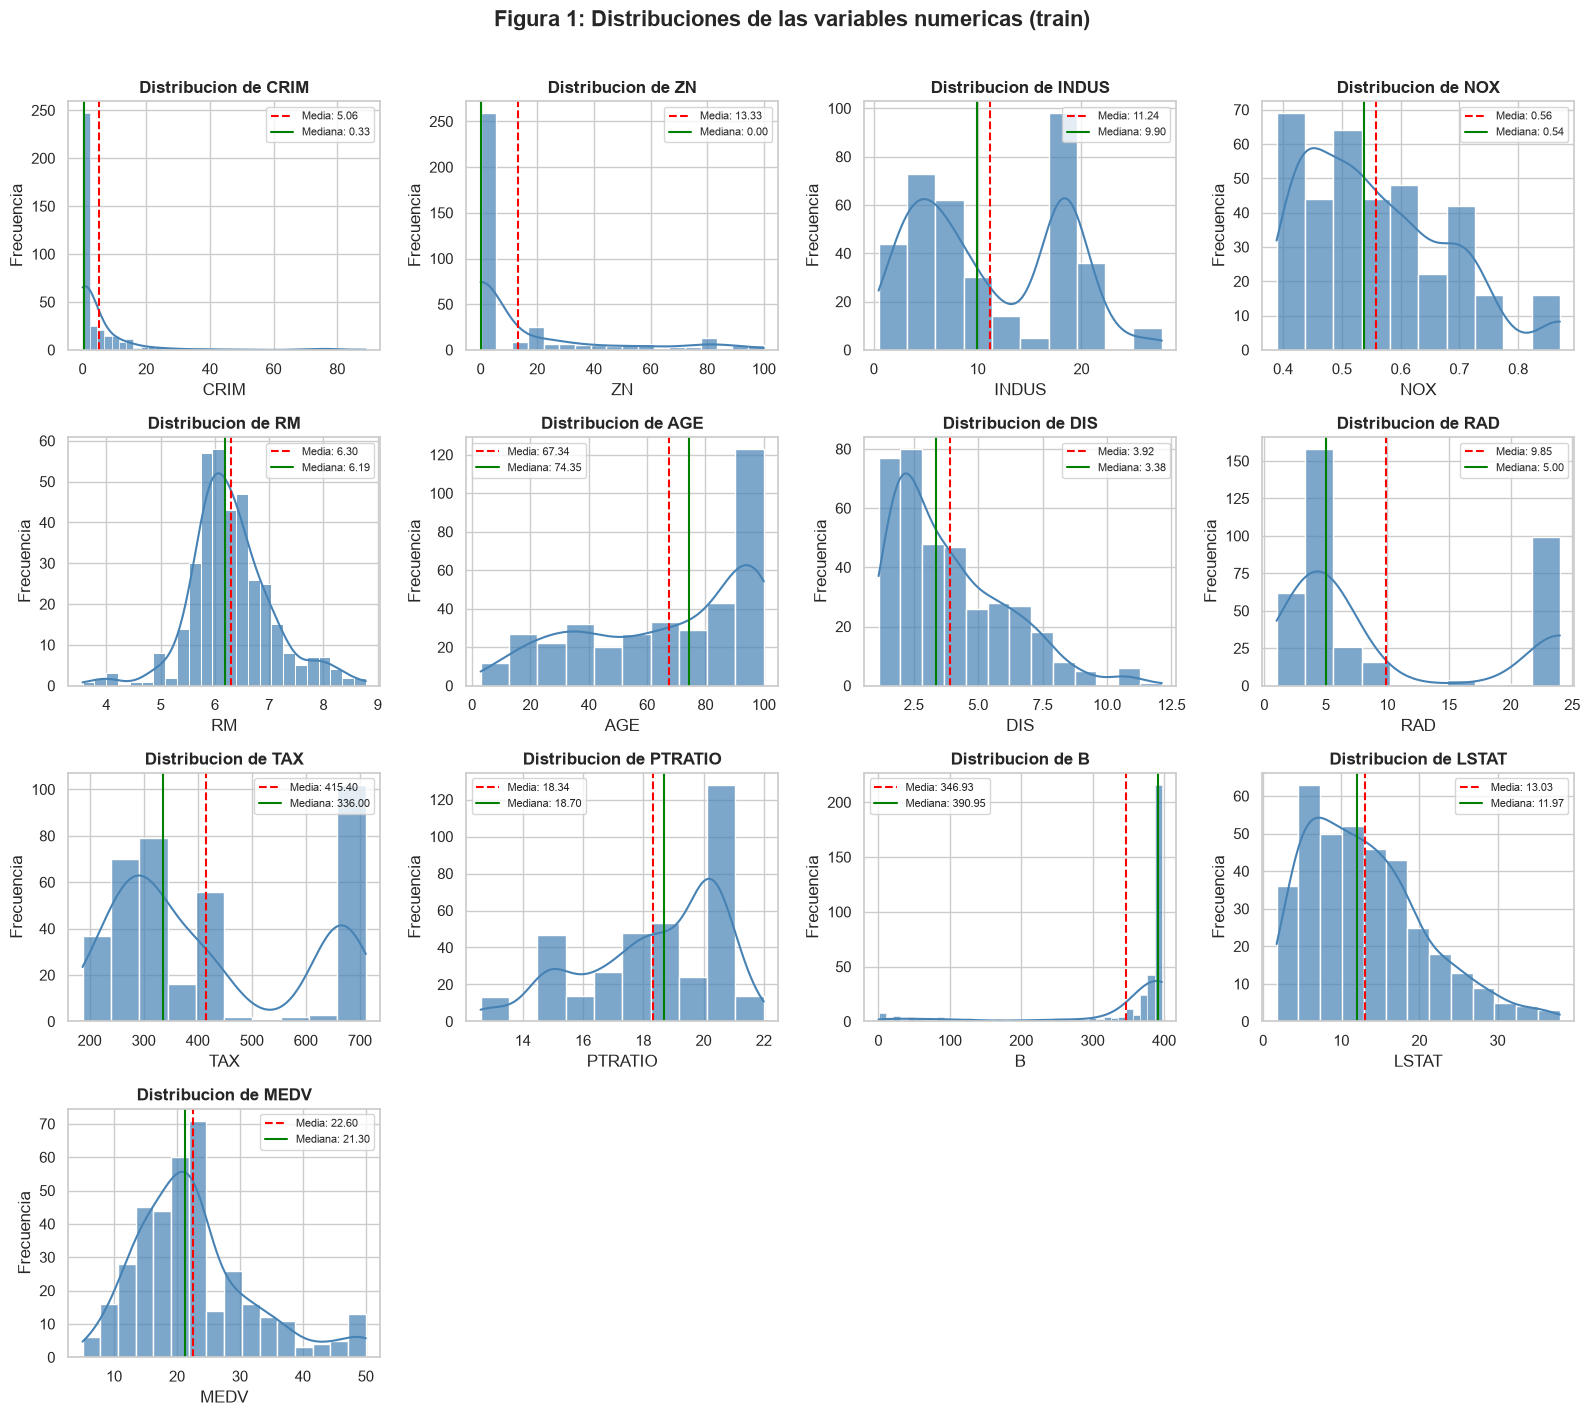

In [10]:
# Figura 1: histogramas de las variables numericas de train con media y mediana (CHAS es binaria, va aparte)
cols_hist = [c for c in data_train.columns if c != 'CHAS']

fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cols_hist):
    ax = axes[i]
    sns.histplot(data_train[col], kde=True, ax=ax, color='steelblue',
                 edgecolor='white', alpha=0.7)

    # Lineas de referencia: media y mediana
    media = data_train[col].mean()
    mediana = data_train[col].median()
    ax.axvline(media, color='red', linestyle='--', linewidth=1.5,
               label=f'Media: {media:.2f}')
    ax.axvline(mediana, color='green', linestyle='-', linewidth=1.5,
               label=f'Mediana: {mediana:.2f}')

    ax.set_title(f'Distribucion de {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

# Desactivar ejes sobrantes si los hay
for j in range(len(cols_hist), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Figura 1: Distribuciones de las variables numericas (train)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Descripción de cada variable** (rangos y medidas de la tabla de estadísticos; forma según la Figura 1):

| Variable | Qué mide | Rango | Comportamiento |
|---|---|---|---|
| `CRIM` | Criminalidad per cápita | 0,006 – 89 | Casi todos los barrios tienen criminalidad baja (mediana 0,33) y unos pocos, muy alta. Es la más asimétrica. |
| `ZN` | % de terreno para lotes residenciales grandes | 0 – 100 | La mediana es 0: al menos la mitad de los barrios no tiene. Cola larga a la derecha. |
| `INDUS` | % de superficie industrial | 0,46 – 27,7 | Dos grupos: barrios poco industriales y un grupo grande en 18,1. |
| `CHAS` | Limita con el río Charles (1) o no (0) | 0 / 1 | Binaria y desbalanceada: la media 0,07 indica que solo ~7% limita con el río. |
| `NOX` | Óxidos de nitrógeno | 0,39 – 0,87 | Rango chico, leve cola a la derecha. |
| `RM` | Habitaciones promedio por vivienda | 3,6 – 8,8 | Bastante simétrica, centrada en ~6,2. |
| `AGE` | % de viviendas anteriores a 1940 | 2,9 – 100 | Predominan las viviendas viejas (mediana 74%). |
| `DIS` | Distancia a centros de empleo | 1,1 – 12,1 | La mayoría está cerca, con cola a la derecha. |
| `RAD` | Índice de acceso a autopistas | 1 – 24 | Dos grupos: la mayoría entre 1 y 8 y otro grupo grande en 24. |
| `TAX` | Impuesto a la propiedad | 187 – 711 | Dos grupos: uno moderado y otro concentrado en 666. |
| `PTRATIO` | Alumnos por docente | 12,6 – 22 | Cola a la izquierda, con muchos barrios en 20,2. |
| `B` | Índice de composición racial | 0,3 – 396,9 | Casi todos los barrios cerca del máximo y unos pocos con valores bajos. |
| `LSTAT` | % de población de bajo nivel socioeconómico | 1,7 – 38 | Cola a la derecha. |
| **`MEDV`** | **Valor mediano de la vivienda (miles USD)** | 5 – 50 | La mitad de los barrios vale entre 16 y 26. Tiene cola de barrios caros y una acumulación en 50. |

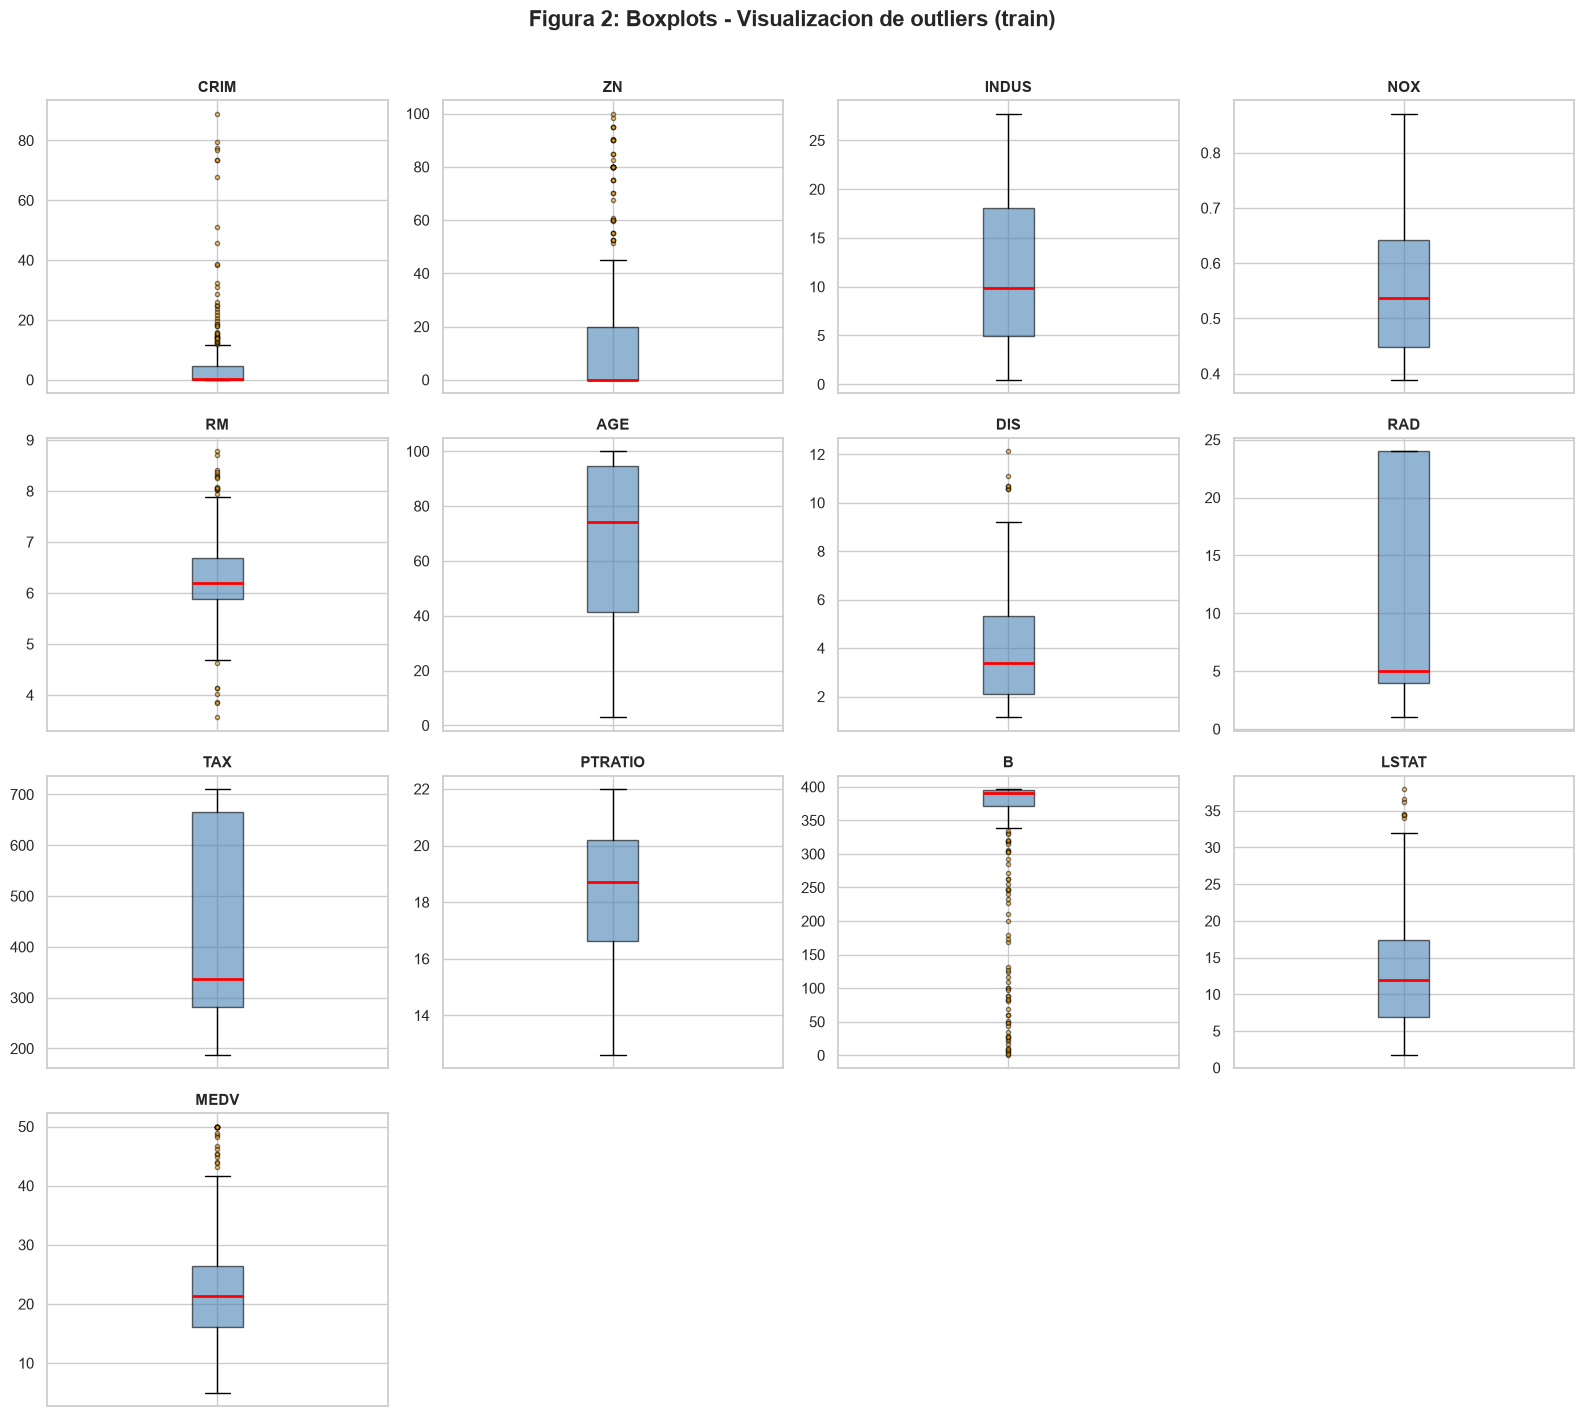

In [11]:
# Figura 2: boxplots de las variables numericas de train
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cols_hist):
    ax = axes[i]
    datos = data_train[col].dropna()

    # vert=True se omite: es el valor por defecto y el parametro esta deprecado en la version de matplotlib instalada
    ax.boxplot(datos, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', markerfacecolor='orange',
                               markersize=3, alpha=0.5))
    ax.set_title(col, fontweight='bold', fontsize=11)
    ax.tick_params(axis='x', labelbottom=False)

for j in range(len(cols_hist), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Figura 2: Boxplots - Visualizacion de outliers (train)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [12]:
# Cantidad y porcentaje de outliers por variable segun el criterio IQR (fuera de Q1 - 1.5*IQR y Q3 + 1.5*IQR)
IQR_FACTOR = 1.5

reporte_outliers = []
for col in cols_hist:
    datos = data_train[col].dropna()
    q1 = datos.quantile(0.25)
    q3 = datos.quantile(0.75)
    iqr = q3 - q1
    outliers_iqr = ((datos < q1 - IQR_FACTOR * iqr) | (datos > q3 + IQR_FACTOR * iqr)).sum()
    reporte_outliers.append({'Variable': col, 'Outliers_IQR': outliers_iqr,
                             'Pct_IQR(%)': outliers_iqr / len(datos) * 100})

pd.DataFrame(reporte_outliers).set_index('Variable').sort_values('Pct_IQR(%)', ascending=False).round(2).T

Variable,B,ZN,CRIM,RM,MEDV,LSTAT,DIS,NOX,INDUS,TAX,RAD,AGE,PTRATIO
Outliers_IQR,64.0000,44.0000,44.0000,22.0000,21.0000,7.0000,7.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Pct_IQR(%),17.4400,12.0500,12.0200,5.9800,5.6100,1.9100,1.8900,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [13]:
# Barrios con MEDV exactamente igual al maximo (50)
print(f'Barrios de train con MEDV = {data_train[TARGET].max()}: {(data_train[TARGET] == data_train[TARGET].max()).sum()}')

Barrios de train con MEDV = 50.0: 10


**Outliers (Figura 2 y tabla):**
- Los que más tienen son `B` (~17%), `CRIM` y `ZN` (~12%), por sus distribuciones muy asimétricas. Son **valores posibles**, no errores: barrios con mucha criminalidad o con todo el terreno para lotes grandes existen.
- **Decisión: se conservan todos.** Eliminarlos limitaría el modelo a barrios "típicos" y superaría el 5% de datos descartados. Esto va a influir en el escalado (sección 10).
- `MEDV` tiene 10 barrios con exactamente 50 (el pico al final de su histograma en la Figura 1). Parece un **tope** en la medición: valen 50 o más. Se conservan, pero el modelo probablemente subestime los barrios más caros.

---
## 7. Relación con el target y correlación

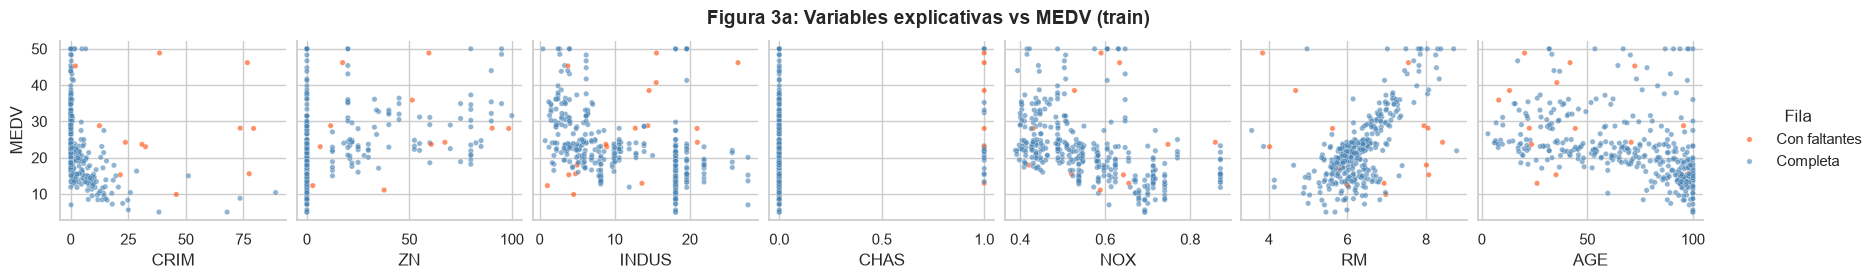

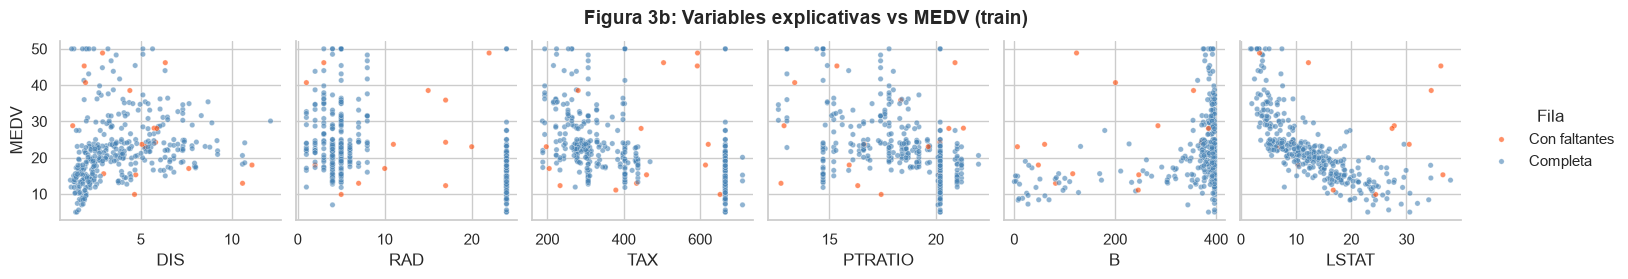

In [14]:
# Figura 3a y 3b: cada variable explicativa contra MEDV, distinguiendo las filas con faltantes
data_plot = data_train.assign(Fila=np.where(filas_con_faltantes, 'Con faltantes', 'Completa'))
paleta = {'Completa': 'steelblue', 'Con faltantes': 'orangered'}

# Se divide en dos graficos para que las 13 variables se lean bien
for parte, x_vars in [('a', cols_features[:7]), ('b', cols_features[7:])]:
    g = sns.pairplot(data_plot, hue='Fila', x_vars=x_vars, y_vars=TARGET,
                     palette=paleta, plot_kws={'alpha': 0.6, 's': 15})
    g.figure.suptitle(f'Figura 3{parte}: Variables explicativas vs MEDV (train)',
                      fontsize=14, fontweight='bold', y=1.08)
    plt.show()

**Figuras 3a y 3b:**
- **`RM`** tiene una relación positiva y casi lineal con el precio. **`LSTAT`**, una relación negativa y **curva**: cae rápido y después se aplana, así que una recta no la captura del todo.
- Las filas con faltantes (naranja) **no siguen el patrón del resto**: aparecen dispersas, con valores que no se corresponden con su precio. Se comportan como **ruido** agregado al dataset.

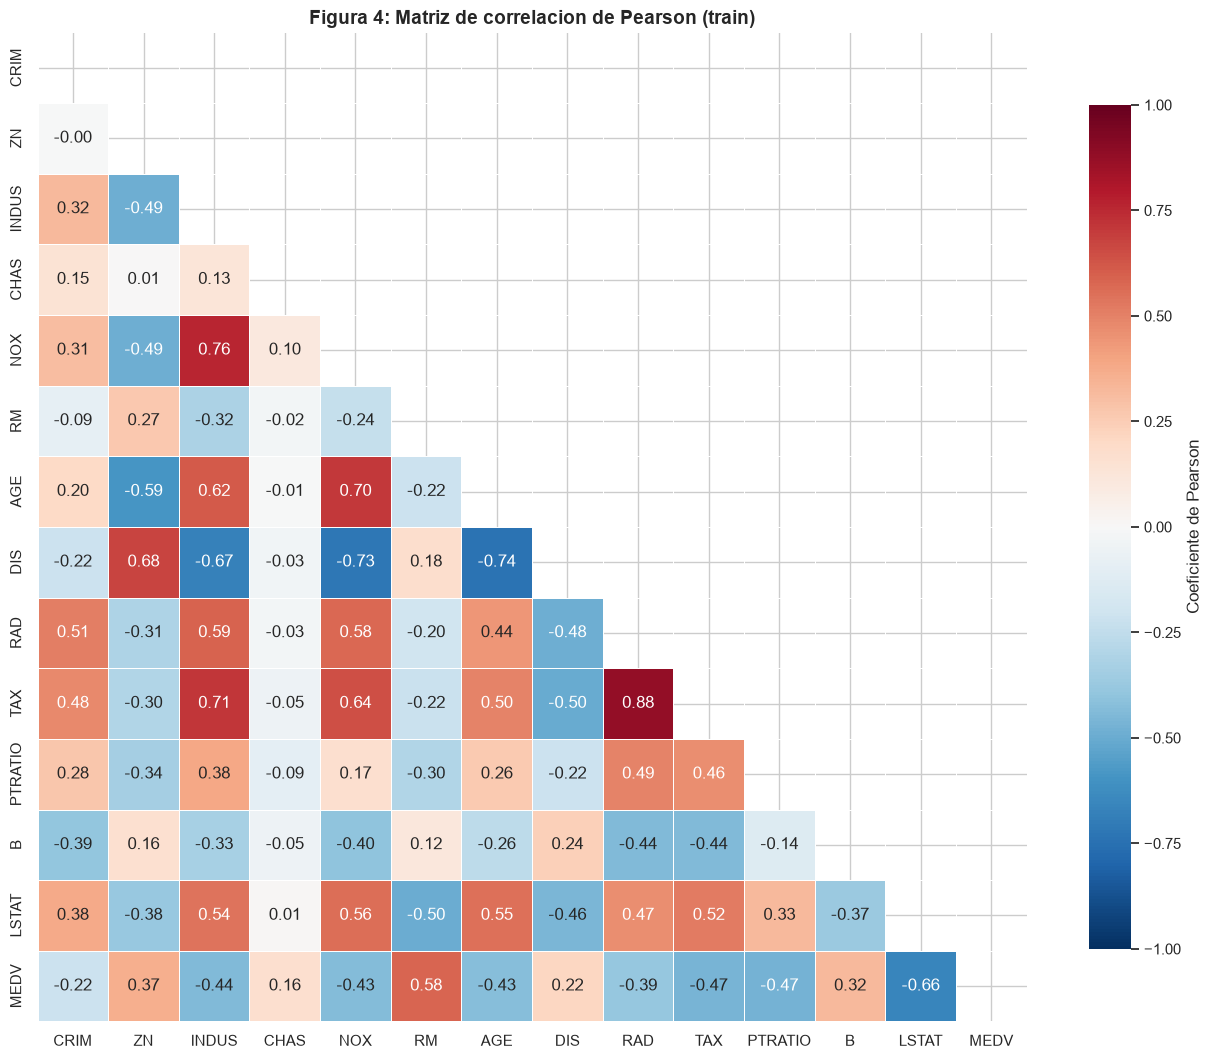

In [15]:
# Figura 4: matriz de correlacion de Pearson con mascara triangular superior
corr_pearson = data_train.corr(method='pearson')
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))

# figsize mayor y 2 decimales para que las 14 variables se lean bien
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr_pearson, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Pearson'})
ax.set_title('Figura 4: Matriz de correlacion de Pearson (train)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
# Correlacion de cada variable con MEDV: Pearson (relacion lineal) vs Spearman (relacion monotona, menos sensible a outliers)
corr_spearman = data_train.corr(method='spearman')

corr_target = pd.DataFrame({
    'Pearson': corr_pearson[TARGET].drop(TARGET),
    'Spearman': corr_spearman[TARGET].drop(TARGET)
})
corr_target.sort_values('Spearman', key=abs, ascending=False).round(2).T

,LSTAT,AGE,RM,TAX,NOX,CRIM,INDUS,PTRATIO,ZN,DIS,RAD,B,CHAS
Pearson,-0.6600,-0.4300,0.5800,-0.4700,-0.4300,-0.2200,-0.4400,-0.4700,0.3700,0.2200,-0.3900,0.3200,0.1600
Spearman,-0.8100,-0.5800,0.5700,-0.5700,-0.5600,-0.5500,-0.5200,-0.5100,0.4400,0.4200,-0.3800,0.2400,0.1100


In [17]:
# VIF de cada variable explicativa, sobre las filas de train sin faltantes (LinearRegression no acepta NaN)
df_vif = X_train.dropna()

vif_resultados = []
for col in cols_features:
    X_vif = df_vif.drop(columns=[col]).values  # X_vif / y_vif para no pisar X e y
    y_vif = df_vif[col].values
    r2 = LinearRegression().fit(X_vif, y_vif).score(X_vif, y_vif)
    vif = 1 / (1 - r2) if r2 < 1 else np.inf
    vif_resultados.append({'Variable': col, 'VIF': vif})

df_vif_result = pd.DataFrame(vif_resultados).sort_values('VIF', ascending=False).set_index('Variable')
df_vif_result.round(2).T

Variable,TAX,RAD,INDUS,NOX,DIS,AGE,LSTAT,ZN,PTRATIO,RM,CRIM,B,CHAS
VIF,9.5100,7.6000,4.6000,4.5500,4.2500,3.2200,2.9500,2.4300,1.9000,1.8600,1.6600,1.4200,1.0800


**Correlación (Figura 4, tabla Pearson vs Spearman y VIF):**
- Con el target, las más fuertes son **`LSTAT` (−0,66)** y **`RM` (+0,58)**, seguidas por `PTRATIO`, `TAX`, `INDUS`, `NOX` y `AGE` (entre −0,43 y −0,47). `CHAS` es la más débil (0,16).
- **Pearson vs Spearman:** las dos coinciden en que `LSTAT` y `RM` son las más fuertes. En `CRIM`, `DIS`, `LSTAT`, `AGE` y `NOX`, Spearman es bastante mayor: la relación existe, pero es curva o está afectada por outliers. Un modelo lineal no la aprovecha del todo. Para la matriz usamos Pearson porque el modelo es lineal: la relación que puede usar, y la colinealidad que lo afecta, son las lineales.
- Entre explicativas, el par más alto es **`TAX`–`RAD` (0,88)**, y el VIF lo confirma: `TAX` ≈ 9,5 y `RAD` ≈ 7,6 indican **colinealidad moderada** (por debajo de 10). `INDUS`, `NOX`, `AGE` y `DIS` también están bastante correlacionadas entre sí (|r| ≥ 0,7).
- **Decisión: no se elimina ninguna variable.** La colinealidad no es severa, y la regularización (consigna 2) está pensada justamente para manejarla.

---
## 8. Codificación de variables categóricas

No hace falta codificar nada. `CHAS`, la única categórica, ya es una variable 0/1. `RAD` es un índice numérico ordenado y se usa como número.

---
## 9. Imputación de faltantes

Se imputa **después** del análisis, porque el análisis es lo que nos dice cómo hacerlo, y **solo con información de train**:
- **`CHAS` (categórica binaria):** moda de train.
- **Numéricas: KMeans.** En las variables con dos grupos (`INDUS`, `RAD`, `TAX`; Figura 1), la mediana (línea verde) le pondría a todos los faltantes el mismo valor: en `RAD` y `TAX`, el del grupo más grande, y en `INDUS`, uno intermedio entre los dos picos, aunque el barrio pertenezca al otro grupo. KMeans agrupa los barrios parecidos según sus otras variables y rellena cada faltante con el valor típico de su grupo: la media en las continuas y la moda en `RAD`, que es un índice y no admite valores intermedios.

KMeans agrupa usando **solo las variables numéricas**, porque `CHAS` se trata aparte como categórica. Para elegir la cantidad de grupos (k) usamos el método del codo y el coeficiente de silueta, sobre las filas completas de train escaladas (KMeans usa distancias, así que las variables tienen que estar en la misma escala).

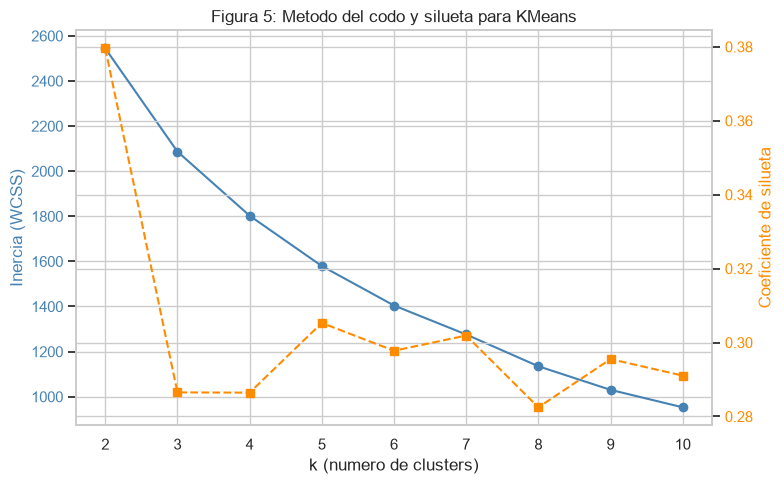

k,2,3,4,5,6,7,8,9,10
inercia,2544.3960,2086.8980,1802.5530,1579.4080,1404.3990,1275.9430,1134.9730,1030.3480,952.9190
silueta,0.3800,0.2870,0.2860,0.3050,0.2980,0.3020,0.2820,0.2960,0.2910


In [18]:
# Figura 5: metodo del codo y silueta para elegir k (KMeans sobre las variables numericas de las filas completas de train, escaladas)
filas_completas = X_train.dropna()
cols_km = [c for c in cols_features if c != 'CHAS']  # CHAS es categorica: se imputa aparte con la moda
scaler_km = StandardScaler().fit(filas_completas[cols_km])
X_scaled = scaler_km.transform(filas_completas[cols_km])

k_range = range(2, 11)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(
        n_clusters=k, n_init=10, random_state=42
    )
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(
        silhouette_score(X_scaled, km.labels_)
    )

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(list(k_range), inertias, "o-", color="steelblue")
ax1.set_xlabel("k (numero de clusters)")
ax1.set_ylabel("Inercia (WCSS)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.plot(
    list(k_range), silhouettes, "s--", color="darkorange"
)
ax2.set_ylabel(
    "Coeficiente de silueta", color="darkorange"
)
ax2.tick_params(axis="y", labelcolor="darkorange")

plt.title("Figura 5: Metodo del codo y silueta para KMeans")
plt.tight_layout()
plt.show()

results = pd.DataFrame(
    {
        "k": list(k_range),
        "inercia": inertias,
        "silueta": silhouettes,
    }
)
results.round(3).set_index('k').T

**Elegimos k = 5** (Figura 5 y tabla):
- La silueta es máxima en k = 2, pero ahí la inercia todavía baja mucho al agregar grupos: con solo dos grupos el agrupamiento es demasiado grueso, y el codo no está en k = 2.
- Entre los demás valores, **k = 5 tiene la mejor silueta**, y a partir de ahí la inercia baja cada vez menos.

In [19]:
# Imputacion: CHAS con la moda de train; numericas con KMeans (k = 5) ajustado solo sobre las filas completas de train
K_CHOSEN = 5

final_km = KMeans(
    n_clusters=K_CHOSEN, n_init=20, random_state=42
)
final_km.fit(X_scaled)

moda_chas = X_train['CHAS'].mode()[0]
medianas_train = X_train.median()

def valor_por_cluster(col):
    # Valor tipico de la columna en cada cluster: moda para RAD (indice discreto), media para las continuas
    grupos = filas_completas[col].groupby(final_km.labels_)
    return grupos.agg(lambda s: s.mode()[0]) if col == 'RAD' else grupos.mean()

def imputar(A):
    B = A.copy()
    B['CHAS'] = B['CHAS'].fillna(moda_chas)
    # Se completa provisoriamente con la mediana solo para poder asignarle un cluster a cada fila
    clusters = pd.Series(final_km.predict(scaler_km.transform(B[cols_km].fillna(medianas_train))), index=A.index)
    for col in cols_km:
        faltan = A[col].isna()
        B.loc[faltan, col] = valor_por_cluster(col).reindex(clusters[faltan]).values
    return B

X_train_imp = imputar(X_train)
X_val_imp = imputar(X_val)
X_test_imp = imputar(X_test)

pd.DataFrame({
    'Valores imputados': [X_train.isna().sum().sum(), X_val.isna().sum().sum(), X_test.isna().sum().sum()],
    'Faltantes despues': [X_train_imp.isna().sum().sum(), X_val_imp.isna().sum().sum(), X_test_imp.isna().sum().sum()],
}, index=['Train', 'Validacion', 'Test'])

,Valores imputados,Faltantes despues
Train,84,0
Validacion,5,0
Test,26,0


In [20]:
# Control: valores asignados a RAD y CHAS en las filas imputadas de train
print(f'RAD imputado: {sorted(X_train_imp.loc[X_train["RAD"].isna(), "RAD"].unique().tolist())}')
print(f'CHAS imputado: {sorted(X_train_imp.loc[X_train["CHAS"].isna(), "CHAS"].unique().tolist())}')

RAD imputado: [4.0, 5.0, 24.0]
CHAS imputado: [0.0]


No quedan faltantes. `RAD` recibió valores distintos según el grupo de cada barrio, incluido el 24 del segundo grupo, algo que la mediana no podría hacer. `CHAS` recibió la moda (0).

---
## 10. Escalado

Las variables tienen escalas muy distintas (`NOX` < 1, `TAX` en cientos; ver la tabla de estadísticos). El descenso de gradiente y la regularización de la consigna 2 necesitan que sean comparables.

**Usamos `RobustScaler`**, que centra con la mediana y divide por el IQR. Como decidimos conservar muchos outliers (sección 6), la media y el desvío de un escalado estándar quedarían muy influenciados por ellos. El escalador se ajusta con train y se aplica igual a validación y test. El target no se escala.

In [21]:
# Escalado robusto: fit solo con train, transform en validacion y test
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled = scaler.transform(X_val_imp)
X_test_scaled = scaler.transform(X_test_imp)

# Verificacion: en train cada variable queda con mediana 0 e IQR 1 (CHAS, con IQR 0, queda como 0/1)
escalado = pd.DataFrame(X_train_scaled, columns=cols_features)
pd.DataFrame({'Mediana': escalado.median(),
              'IQR': escalado.quantile(0.75) - escalado.quantile(0.25)}).round(2).T

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
Mediana,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000
IQR,1.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


---
## 11. Conclusiones

1. El dataset tiene **506 filas completas y 50 filas** que concentran todos los faltantes y no siguen el patrón del resto (Figura 3): se comportan como ruido.
2. **Ninguna variable tiene valores imposibles** salvo `RAD`, que se corrigió. Hay muchos outliers, pero son valores reales y se conservan.
3. **`LSTAT` y `RM`** son las variables más relacionadas con el precio. Varias relaciones son **curvas** (Spearman bastante mayor que Pearson en `LSTAT`, `CRIM` y `DIS`): un modelo lineal no las va a capturar del todo.
4. **`TAX` y `RAD`** tienen colinealidad moderada. No se eliminan variables; lo va a manejar la regularización.
5. El precio está **topeado en 50**: es probable que el modelo subestime los barrios más caros.

| Decisión | Motivo |
|---|---|
| Eliminar las 21 filas sin `MEDV` (3,8%) | Sin target no se puede entrenar ni evaluar |
| Conservar las 50 filas con faltantes | Eliminarlas superaría el 5% de datos descartados |
| Redondear los `RAD` no enteros | `RAD` es un índice entero |
| Split 70/10/20 antes de analizar | Evitar que validación y test influyan en las decisiones |
| Conservar outliers | Son valores reales |
| No eliminar variables | La colinealidad es moderada |
| Imputar `CHAS` con la moda | Es categórica binaria |
| Imputar las numéricas con KMeans (k = 5) | Respeta los dos grupos de las variables bimodales (Figura 1); k elegido con codo y silueta (Figura 5) |
| Escalar con `RobustScaler` | Resiste los outliers que conservamos |